In [1]:
import numpy as np
import pandas as pd

In [2]:
visits = pd.read_csv('metrika_visits.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_15728\2045387353.py:1: DtypeWarning: Columns (1,4,13) have mixed types. Specify dtype option on import or set low_memory=False.
  visits = pd.read_csv('metrika_visits.csv')


In [3]:
visits.columns

Index(['project_id', 'visit_id', 'date_time', 'is_new_user', 'client_id',
       'region_country', 'region_city', 'watch_ids', 'traffic_source',
       'adv_engine', 'search_engine_root', 'search_engine', 'social_network',
       'recommendation_system', 'messenger', 'device_category', 'mobile_phone',
       'mobile_phone_model', 'operating_system_root', 'operating_system',
       'browser', 'browser_major_version', 'screen_width', 'screen_height'],
      dtype='object')

In [4]:
import ast
if isinstance(visits['watch_ids'].iloc[0], str):
    visits['watch_ids'] = visits['watch_ids'].apply(ast.literal_eval)

# 2. Explode the list column
# This creates a row for every watch_id in the list
visits_exploded = visits.explode('watch_ids')

# 3. Rename the column for clarity and remove any nulls
visits_exploded = visits_exploded.rename(columns={'watch_ids': 'watch_id'})
visits_exploded = visits_exploded.dropna(subset=['watch_id'])

# 4. Verify the transformation
print(f"Original unique visits: {len(visits)}")
print(f"Total rows after exploding: {len(visits_exploded)}")

Original unique visits: 345214
Total rows after exploding: 2902833


In [5]:
hits_prod = pd.read_csv('metrika_hits.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_15728\799770026.py:1: DtypeWarning: Columns (1,3,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  hits_prod = pd.read_csv('metrika_hits.csv')


In [6]:
hits_prod.isna().sum()

project_id                           0
watch_id                             0
date_time                            0
client_id                            0
region_country                    7811
region_city                     320244
url                                  0
page_type                            0
slug                            318016
artificial                           0
is_page_view                         0
not_bounce                           0
link                                 0
download                             0
last_traffic_source                  0
last_search_engine_root        1599228
last_search_engine             1599228
last_adv_engine                1558205
last_social_network            1736733
last_social_network_profile    1757589
recommendation_system          1738574
messenger                      1755119
device_category                      0
mobile_phone                    395858
mobile_phone_model              389016
operating_system_root    

In [7]:
hits_prod['date_time'] = pd.to_datetime(hits_prod['date_time'], format='ISO8601')
visits['date_time'] = pd.to_datetime(visits['date_time'], format='ISO8601')
hits_prod = hits_prod.sort_values('date_time')
visits = visits.sort_values('date_time')

In [8]:
visits.drop(columns=['project_id'], inplace=True)

In [9]:
# # 2. Sort both DataFrames by the timestamp
# enriched_hits = pd.merge_asof(hits_prod.sort_values('date_time'), 
#                        visits.sort_values('date_time').rename(columns={'date_time': 'v_date_time'}), 
#                        left_on='date_time', right_on='v_date_time', by='client_id', 
#                        direction='backward', tolerance=pd.Timedelta('2h'))

In [10]:
# hits_new = hits[hits['project_id'] == 0]
# hits_new

In [11]:
# hits_prod = hits[hits['page_type'] == 'PRODUCT']
# hits_prod

In [9]:
hits_prod['client_id'].isin(visits_exploded['client_id']).sum()

1622059

In [10]:
hits_prod.columns

Index(['project_id', 'watch_id', 'date_time', 'client_id', 'region_country',
       'region_city', 'url', 'page_type', 'slug', 'artificial', 'is_page_view',
       'not_bounce', 'link', 'download', 'last_traffic_source',
       'last_search_engine_root', 'last_search_engine', 'last_adv_engine',
       'last_social_network', 'last_social_network_profile',
       'recommendation_system', 'messenger', 'device_category', 'mobile_phone',
       'mobile_phone_model', 'operating_system_root', 'operating_system',
       'browser', 'browser_major_version', 'screen_width', 'screen_height'],
      dtype='object')

In [11]:
hits_prod = hits_prod.drop(columns=['region_country',
                                           'region_city', 'url','artificial', 'link', 'download', 'last_traffic_source',
                                           'last_search_engine_root', 'last_search_engine', 'last_adv_engine',
                                           'last_social_network', 'last_social_network_profile',
                                           'recommendation_system', 'messenger', 'device_category', 'mobile_phone',
                                           'mobile_phone_model', 'operating_system_root', 'operating_system',
                                           'browser', 'browser_major_version', 'screen_width', 'screen_height'], axis=1)

In [12]:
old_site_p = pd.read_csv('old_site_products.csv')
new_site_p = pd.read_csv('new_site_products.csv')
cols_to_keep = ['id', 'name', 'brand', 'main_category', 'categories', 'slug']
old_site_p = old_site_p[cols_to_keep]
new_site_p = new_site_p[cols_to_keep]

In [13]:
mapping = pd.read_csv('old_site_new_site_products.csv')

In [16]:
hits_prod['slug'].isin(old_site_p['slug']).sum()

387950

In [17]:
new_slug_to_pid = dict(zip(new_site_p['slug'], new_site_p['id']))
cat_to_pid = dict(zip(new_site_p['main_category'], new_site_p['id']))
brand_to_pid = dict(zip(new_site_p['brand'], new_site_p['id']))
old_slug_to_pid = dict(zip(old_site_p['slug'], old_site_p['id']))

In [18]:
def map_product_id(row):
    if row['project_id'] == 1:
        # Use the old site dictionary
        return old_slug_to_pid.get(row['slug'])
    else:
        # Use the new site dictionary (default for project_id 0)
        return new_slug_to_pid.get(row['slug'])

# Apply the function to create the new column
hits_prod['product_id'] = hits_prod.apply(map_product_id, axis=1)
hits_prod.isna().sum()

project_id            0
watch_id              0
date_time             0
client_id             0
page_type             0
slug             318016
is_page_view          0
not_bounce            0
product_id      1273625
dtype: int64

In [19]:
hits_prod.columns

Index(['project_id', 'watch_id', 'date_time', 'client_id', 'page_type', 'slug',
       'is_page_view', 'not_bounce', 'product_id'],
      dtype='object')

In [73]:
# enriched_hits.dropna(subset=['product_id'], inplace=True)
# enriched_hits.drop(columns=['region_country_x',
#        'region_city_x', 'url', 'artificial',
#        'is_page_view', 'not_bounce', 'link', 'download', 'last_traffic_source',
#        'last_search_engine_root', 'last_search_engine', 'last_adv_engine',
#        'last_social_network', 'last_social_network_profile',
#        'recommendation_system_x', 'messenger_x', 'device_category_x',
#        'mobile_phone_x', 'mobile_phone_model_x', 'operating_system_root_x',
#        'operating_system_x', 'browser_x', 'browser_major_version_x',
#        'screen_width_x', 'screen_height_x', 'is_new_user', 'region_country_y', 'region_city_y', 'traffic_source', 'adv_engine', 'search_engine_root', 'search_engine',
#        'social_network', 'recommendation_system_y', 'messenger_y',
#        'device_category_y', 'mobile_phone_y', 'mobile_phone_model_y',
#        'operating_system_root_y', 'operating_system_y', 'browser_y',
#        'browser_major_version_y', 'screen_width_y', 'screen_height_y'], inplace=True)

In [21]:
len(hits_prod['product_id'].unique())

1209

In [52]:
old_to_new_map = dict(zip(mapping['old_site_id'], mapping['new_site_id']))

# If the hit was on the old site, translate the ID to the new site equivalent
def translate_to_new(row):
    if row['product_id'] <= 10000: # Old site
        return old_to_new_map.get(row['product_id'])
    return row['product_id'] # Already a new site ID or NaN

hits_prod['product_id'] = hits_prod.apply(translate_to_new, axis=1)
hits_prod.isna().sum()

project_id          0
watch_id            0
date_time           0
client_id           0
page_type           0
slug                0
is_page_view        0
not_bounce          0
product_id      77131
dtype: int64

In [53]:
len(hits_prod['product_id'].unique())

595

In [54]:
hits_prod = hits_prod.dropna()
hits_prod.isna().sum()

project_id      0
watch_id        0
date_time       0
client_id       0
page_type       0
slug            0
is_page_view    0
not_bounce      0
product_id      0
dtype: int64

In [55]:
visits_exploded = visits_exploded.sort_values('date_time')

In [56]:
hits_prod['client_id'].isin(visits_exploded['client_id']).sum()

369644

In [57]:
hits_prod.shape

(406863, 9)

In [58]:
hits_prod['date_time'] = pd.to_datetime(hits_prod['date_time'], format='ISO8601')
visits['date_time'] = pd.to_datetime(visits['date_time'], format='ISO8601')
hits_prod = hits_prod.sort_values('date_time')
visits = visits.sort_values('date_time')

In [59]:
visits_exploded.columns

Index(['project_id', 'visit_id', 'date_time', 'is_new_user', 'client_id',
       'region_country', 'region_city', 'watch_id', 'traffic_source',
       'adv_engine', 'search_engine_root', 'search_engine', 'social_network',
       'recommendation_system', 'messenger', 'device_category', 'mobile_phone',
       'mobile_phone_model', 'operating_system_root', 'operating_system',
       'browser', 'browser_major_version', 'screen_width', 'screen_height'],
      dtype='object')

In [63]:
hits_prod['date_time'] = pd.to_datetime(hits_prod['date_time'], format='ISO8601')
visits_exploded['date_time'] = pd.to_datetime(visits_exploded['date_time'], format='ISO8601')
hits_prod = hits_prod.sort_values('date_time')
visits = visits.sort_values('date_time')


# enriched_hits = hits_prod.merge(
#     visits[['client_id', 'date_time', 'visit_id']].rename(columns={'date_time': 'v_date_time'}), 
#     on='date_time', 
#     how='inner'
# )

enriched_hits = pd.merge_asof(hits_prod.sort_values('date_time'), 
                       visits.sort_values('date_time').rename(columns={'date_time': 'v_date_time'}), 
                       left_on='date_time', right_on='v_date_time', by='client_id', 
                       direction='backward', tolerance=pd.Timedelta('2h'))
enriched_hits.shape

(406863, 31)

In [64]:
enriched_hits.isna().sum()

project_id                    0
watch_id                      0
date_time                     0
client_id                     0
page_type                     0
slug                          0
is_page_view                  0
not_bounce                    0
product_id                    0
visit_id                  45302
v_date_time               45302
is_new_user               45302
region_country            46954
region_city               99815
watch_ids                 45302
traffic_source            45302
adv_engine                45302
search_engine_root       249555
search_engine            249555
social_network           396015
recommendation_system    402073
messenger                406141
device_category           45302
mobile_phone             140509
mobile_phone_model       140084
operating_system_root     46200
operating_system          46200
browser                   45307
browser_major_version     45302
screen_width              45302
screen_height             45302
dtype: i

In [65]:
len(enriched_hits['slug'].unique())

927

In [66]:
len(enriched_hits['product_id'].unique())

594

In [67]:
enriched_hits['product_id'] = enriched_hits['product_id'].astype('int64')
enriched_hits.dtypes

project_id                        int64
watch_id                         object
date_time                datetime64[ns]
client_id                        object
page_type                        object
slug                             object
is_page_view                      int64
not_bounce                        int64
product_id                        int64
visit_id                         object
v_date_time              datetime64[ns]
is_new_user                     float64
region_country                   object
region_city                      object
watch_ids                        object
traffic_source                   object
adv_engine                       object
search_engine_root               object
search_engine                    object
social_network                   object
recommendation_system            object
messenger                        object
device_category                 float64
mobile_phone                     object
mobile_phone_model               object


In [68]:
enriched_hits[enriched_hits['product_id'] <= 10000]

,project_id,watch_id,date_time,client_id,page_type,slug,is_page_view,not_bounce,product_id,visit_id,...,messenger,device_category,mobile_phone,mobile_phone_model,operating_system_root,operating_system,browser,browser_major_version,screen_width,screen_height


In [69]:
enriched_hits.shape

(406863, 31)

In [70]:
enriched_hits = enriched_hits.sort_values(['visit_id', 'date_time'])

# 2. Group into lists of sequences
sequences = enriched_hits.groupby('visit_id').agg({'product_id': list})
sequences

,product_id
visit_id,
12762478139494,"[495492744, 495493530, 495492744, 495493530]"
31960843868541,"[495368878, 495368878, 495507034, 495507034, 4..."
150447116176660,"[495250885, 495250885, 495250885, 495250885, 4..."
194561822133345,"[463480553, 463480553, 463480589]"
301432419943766,"[495400618, 495400618, 495400618]"
...,...
9999168946251644290,[495529087]
99993986280672043165,"[495514529, 495514529]"
9999431836130268904,"[495399975, 463480350, 463480350, 463480350, 4..."


In [71]:
sequences[sequences['product_id'].apply(lambda x: len(x) >= 2)]

,product_id
visit_id,
12762478139494,"[495492744, 495493530, 495492744, 495493530]"
31960843868541,"[495368878, 495368878, 495507034, 495507034, 4..."
150447116176660,"[495250885, 495250885, 495250885, 495250885, 4..."
194561822133345,"[463480553, 463480553, 463480589]"
301432419943766,"[495400618, 495400618, 495400618]"
...,...
9999057989015655840,"[495399696, 495399696, 495399975, 495399700]"
9999110073398160389,"[495400314, 495400314]"
99993986280672043165,"[495514529, 495514529]"


In [72]:
from collections import Counter

Counter(sequences['product_id'].apply(lambda x: len(x)))

Counter({1: 38739,
         2: 31619,
         3: 12265,
         4: 8918,
         5: 5531,
         6: 3036,
         7: 1872,
         8: 1843,
         9: 1405,
         10: 1000,
         12: 689,
         11: 618,
         13: 548,
         14: 411,
         16: 354,
         15: 335,
         17: 305,
         18: 210,
         20: 180,
         19: 143,
         21: 121,
         24: 104,
         22: 98,
         25: 89,
         23: 84,
         28: 60,
         26: 58,
         27: 48,
         32: 47,
         29: 42,
         30: 41,
         33: 26,
         37: 26,
         34: 25,
         31: 23,
         36: 22,
         38: 20,
         35: 18,
         43: 14,
         40: 13,
         41: 13,
         45: 12,
         46: 11,
         39: 10,
         44: 9,
         52: 8,
         48: 7,
         54: 7,
         49: 6,
         50: 6,
         42: 6,
         56: 5,
         62: 5,
         53: 4,
         63: 4,
         57: 4,
         61: 4,
         68: 4,
  

In [143]:
sequences[sequences['product_id'].apply(lambda x: len(x) == 11)]['product_id']

visit_id
8064964521766445146    [463480221.0, 463480497.0, 463480497.0, 463480...
Name: product_id, dtype: object

<function matplotlib.pyplot.show(close=None, block=None)>

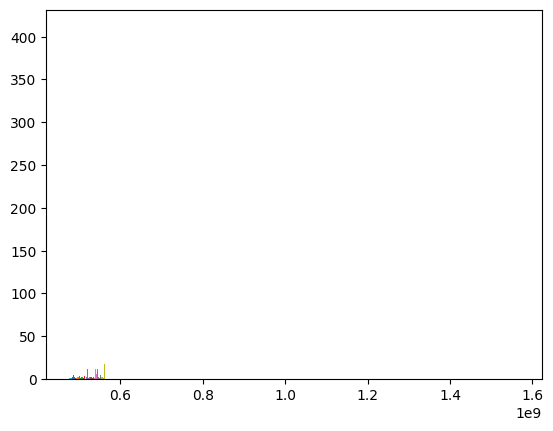

In [73]:
import matplotlib.pyplot as plt
plt.hist(sequences['product_id'])
plt.show

In [55]:
sequences['product_id'] = sequences[sequences['product_id'].apply(lambda x: len(x) >= 2)]

In [56]:
sequences

,product_id
visit_id,
12762478139494,NaN
194561822133345,NaN
301432419943766,"[495400618.0, 495400618.0]"
405728205807658,NaN
458153696400432,NaN
...,...
9998791523963942759,NaN
9999057989015655840,NaN
9999110073398160389,NaN


In [57]:
sequences.dropna(inplace=True)

In [58]:
sequences

,product_id
visit_id,
301432419943766,"[495400618.0, 495400618.0]"
5752194199488316,"[463480693.0, 463480693.0]"
12811461182753779,"[463480226.0, 463480226.0]"
19785702398655900,"[495400314.0, 495400314.0]"
20851335427453159,"[463480256.0, 463480256.0, 463480256.0, 463480..."
...,...
9980374974803036646,"[463480242.0, 463480242.0]"
9982771101523665364,"[463480497.0, 463480497.0]"
9988715156365526448,"[463480697.0, 463480697.0]"


In [26]:
sequences.to_csv('co-occurence_sequences.csv')

In [11]:
len(enriched_hits['slug'].unique())

729

In [14]:
old_new_concat = pd.concat([old_site_p, new_site_p])
old_new_concat

,id,name,brand,main_category,categories,slug
0,3259,Автокресло Baby Care BSO Sport Isofix,Baby Care,Автокресла,"[""Автокресла"",""Прогулки и путешествия""]",avtokreslo-baby-care-bso-sport-isofix
1,3261,Автокресло Chicco Key1 X-Plus ISOFIX,Chicсo,Автокресла,"[""Автокресла"",""Прогулки и путешествия""]",avtokreslo-chicco-key1-x-plus-isofix
2,3262,Автокресло Chicco Synthesis XT-Plus,Chicсo,Автокресла,"[""Автокресла"",""Прогулки и путешествия""]",avtokreslo-chicco-synthesis-xt-plus
3,3265,Дом-палатка с туннелем «Океан»,Ching-Ching,Домики и палатки,"[""Домики и палатки"",""Тренажеры и игровые компл...",dom-palatka-s-tunnelem-okean
4,3267,Барабан для малышей,Imaginarium,NaN,[],baraban-dlya-malyshey
...,...,...,...,...,...,...
683,1651502137,Адаптеры для автолюльки Yoyo,BabyZen,Коляски,"[""Коляски""]",adaptery-dlya-avtolyulki-yoyo
684,1655011689,Электрокачели MamaRoo NEW + весы Maman напрокат,Maman##4moms,Акции недели,"[""Акции недели"",""Качели, шезлонги"",""Весы""]",elektrokacheli-mamaroo-new-vesy-maman-naprokat
685,1677458905,Обезьянка на кольцах напрокат,Bright Starts,Музыкальные игрушки,"[""Развивающие игрушки"",""Музыкальные игрушки""]",obezyanka-na-koltsah-naprokat
686,1677460825,"Развивающая игрушка ""Маленькие друзья"" напрокат",Fisher-Price,Музыкальные игрушки,"[""Развивающие игрушки"",""Музыкальные игрушки""]",razvivayuschaya-igrushka-malenkie-druzya-naprokat


In [15]:
enriched_hits_merged = enriched_hits.merge(old_new_concat, on='slug', how='left')
print(enriched_hits_merged.shape)
print(enriched_hits_merged.isna().sum())

(194623, 15)
project_id            0
watch_id              0
date_time             0
client_id             0
page_type             0
slug              37429
is_page_view          0
not_bounce            0
visit_id              0
is_new_user           0
id               142954
name             142954
brand            142981
main_category    143386
categories       142954
dtype: int64


In [16]:
enriched_hits_merged['slug'] = enriched_hits_merged['slug'].fillna('UNKNOWN')
enriched_hits_merged[enriched_hits_merged['slug'] == 'UNKNOWN']

,project_id,watch_id,date_time,client_id,page_type,slug,is_page_view,not_bounce,visit_id,is_new_user,id,name,brand,main_category,categories
1,1,6083735844269182826,2021-12-22T22:28:59,8231705439711639076,MAIN,UNKNOWN,0,1,2514991113289479317,1,NaN,NaN,NaN,NaN,NaN
2,1,4602426825534813428,2021-12-22T22:29:16,3471885286468951795,MAIN,UNKNOWN,1,0,4602426825534813428,1,NaN,NaN,NaN,NaN,NaN
3,1,0540455002429536660,2021-12-22T22:29:18,3471885286468951795,MAIN,UNKNOWN,1,0,4602426825534813428,1,NaN,NaN,NaN,NaN,NaN
7,1,1539290260371485224,2021-12-22T22:29:32,3471885286468951795,MAIN,UNKNOWN,0,1,4602426825534813428,1,NaN,NaN,NaN,NaN,NaN
16,1,7462194755248926481,2021-12-22T22:34:01,021131056973009366,MAIN,UNKNOWN,1,0,7462194755248926481,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194583,1,797197988336218981,2025-02-02T10:01:51,1319473386812175951,MAIN,UNKNOWN,1,0,797197988336218981,1,NaN,NaN,NaN,NaN,NaN
194585,1,927761660030977473,2025-02-02T10:04:12,8438964342739742098,MAIN,UNKNOWN,1,0,927761660030977473,1,NaN,NaN,NaN,NaN,NaN
194592,1,572551366397148632,2025-02-02T10:05:27,8438964342739742098,MAIN,UNKNOWN,1,0,927761660030977473,1,NaN,NaN,NaN,NaN,NaN
194612,1,614303503581490437,2025-02-02T10:56:47,3521366576396512936,CART,UNKNOWN,1,0,613818631647200492,0,NaN,NaN,NaN,NaN,NaN


In [55]:
enriched_hits_merged['date_time'] = pd.to_datetime(enriched_hits_merged['date_time'], format='ISO8601')

enriched_hits_merged = enriched_hits_merged.sort_values(['visit_id', 'date_time'])

# 2. Group by visit_id to see the sequence of URLs/Slugs
user_journeys = enriched_hits_merged.groupby(['visit_id']).agg({'slug' : list, 'id': list}).reset_index()

# 3. View a sample journey
print(user_journeys.shape)

(40593, 3)


In [57]:
user_journeys

,visit_id,slug,id
0,1478092229145392,"[UNKNOWN, ROOT, manezhi-i-krovatki, manezhi-i-...","[nan, nan, nan, nan, 3572.0, nan, 3466.0, nan,..."
1,3300925936098714,"[UNKNOWN, UNKNOWN]","[nan, nan]"
2,4215450036644604,[kacheli-i-kachalki],[nan]
3,9796208045460031,"[UNKNOWN, ROOT, detskie-vesy, vesy-laica-ps-30...","[nan, nan, nan, 3384.0, 3384.0, nan, nan, nan]"
4,13359493122602930,[kacheli-i-kachalki],[nan]
...,...,...,...
40588,99962119119578579322,"[elektrokacheli, kacheli-elektronnye-komfort-i...","[nan, 3544.0, nan, nan]"
40589,9996514530276671627,[mashina-tolokar-s-ruchkoy-range-rover-sport],[3602.0]
40590,99968006727143760123,"[UNKNOWN, UNKNOWN]","[nan, nan]"
40591,99986245066202684,"[UNKNOWN, razvivayuschie-igrushki, razvivayusc...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


In [58]:
user_journeys.drop(columns = ['id'], axis=1, inplace=True)
user_journeys

,visit_id,slug
0,1478092229145392,"[UNKNOWN, ROOT, manezhi-i-krovatki, manezhi-i-..."
1,3300925936098714,"[UNKNOWN, UNKNOWN]"
2,4215450036644604,[kacheli-i-kachalki]
3,9796208045460031,"[UNKNOWN, ROOT, detskie-vesy, vesy-laica-ps-30..."
4,13359493122602930,[kacheli-i-kachalki]
...,...,...
40588,99962119119578579322,"[elektrokacheli, kacheli-elektronnye-komfort-i..."
40589,9996514530276671627,[mashina-tolokar-s-ruchkoy-range-rover-sport]
40590,99968006727143760123,"[UNKNOWN, UNKNOWN]"
40591,99986245066202684,"[UNKNOWN, razvivayuschie-igrushki, razvivayusc..."


In [59]:
user_journeys.to_csv('user_journeys.csv', index=False)

In [29]:
old_slug_to_id = dict(zip(old_site_p['slug'], old_site_p['id']))
new_slug_to_id = dict(zip(new_site_p['slug'], new_site_p['id']))

In [30]:
merged_dict = old_slug_to_id | new_slug_to_id
len(merged_dict)

1424

In [31]:
unique_slugs_df = pd.DataFrame(enriched_hits_merged['slug'].unique(), columns=['slug'])


unique_slugs_df['pid_is_available'] = unique_slugs_df['slug'].isin(merged_dict.keys()).astype(int)

print(unique_slugs_df.shape)

(729, 2)


In [32]:
match_count = unique_slugs_df['pid_is_available'].sum()
print(f"Matched: {match_count} / {len(unique_slugs_df)}")

Matched: 655 / 729


In [33]:
unique_slugs_df = unique_slugs_df[~unique_slugs_df['slug'].isna()]
unique_slugs_df

,slug,pid_is_available
0,UNKNOWN,0
1,ROOT,0
2,manezhi-i-krovatki,0
3,krovatka-chicco-next2me,1
4,krovatka-manezh-chicco-zipgo,1
...,...,...
724,gamak-krovatka-kidwood,1
725,avtokreslo-maxi-cosi-pebble-crazy-mamas,1
726,gonki-elc,1
727,mobil-druzya-iz-tropicheskogo-lesa-popugay,1


In [34]:
unique_slugs_df.to_csv('unique_slugs_df.csv', index = False)

In [38]:
unique_slugs_embeddings = pd.read_csv('unique_slugs_embeddings.csv')

In [40]:
unique_slugs_embeddings['product_id'] = unique_slugs_embeddings['slug'].map(merged_dict)
unique_slugs_embeddings

,Unnamed: 0,slug,pid_is_available,embeddings,product_id
0,0,ROOT,0,[ 1.56962778e-02 -4.57994342e-02 1.84462667e-...,NaN
1,1,manezhi-i-krovatki,0,[ 2.66767032e-02 -1.90703776e-02 3.84690240e-...,NaN
2,2,krovatka-chicco-next2me,1,[ 0.05553827 -0.08089578 0.03729409 -0.016796...,3572.0
3,3,krovatka-manezh-chicco-zipgo,1,[ 2.78634150e-02 -8.13705251e-02 6.06315248e-...,3466.0
4,4,skladnaya-krovatka-snuggle-nest-surround-khl,1,[ 1.00846952e-02 -7.04894662e-02 4.13043872e-...,3825.0
...,...,...,...,...,...
723,723,gamak-krovatka-kidwood,1,[ 4.47303765e-02 -8.11619237e-02 1.22936862e-...,3387.0
724,724,avtokreslo-maxi-cosi-pebble-crazy-mamas,1,[ 3.21396068e-02 -6.85035065e-02 7.52658993e-...,6667.0
725,725,gonki-elc,1,[ 3.71554382e-02 -6.34240359e-02 -1.09364707e-...,3409.0
726,726,mobil-druzya-iz-tropicheskogo-lesa-popugay,1,[ 3.88050713e-02 -1.89655311e-02 5.25056347e-...,495519046.0


In [ ]:
unique_slugs_embeddings['product_id'] = unique_slugs_embeddings['product_id'].fillna(-1)
unique_slugs_embeddings

In [ ]:
unique_slugs_embeddings.to_csv('unique_slugs_embeddings.csv', index=False)